In [78]:
!pip install xlrd
!pip install python-calamine

## Upload the file, turn each separate list into a column

In [79]:
import pandas as pd
import re


file_path = r"C:\Users\danma\Downloads\imf-dm-export-20260204.xls"
COUNTRY = "Russian Federation"

all_sheets = pd.read_excel(file_path, sheet_name=None, engine="calamine")

def to_series_for_country(sheet_name: str, df: pd.DataFrame, country: str) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    # First column contains the country names (plus blanks / copyright rows)
    first_col = df.columns[0]

    # Find the row for the target country
    row_mask = df[first_col].astype(str).str.strip().eq(country)
    if not row_mask.any():
        return pd.DataFrame(columns=["Year", sheet_name])

    row = df.loc[row_mask].iloc[0]

    # Year columns are the ones that look like 4-digit years
    year_cols = []
    for c in df.columns[1:]:
        s = str(c).strip()
        if re.fullmatch(r"\d{4}", s):
            year_cols.append(c)

    # Build long (Year, value) for this indicator
    out = pd.DataFrame({
        "Year": [int(str(c).strip()) for c in year_cols],
        sheet_name: pd.to_numeric(row[year_cols], errors="coerce").values
    })

    return out

series_dfs = []
for sheet_name, df in all_sheets.items():
    s = to_series_for_country(sheet_name, df, COUNTRY)
    if not s.empty:
        series_dfs.append(s)

# Merge all indicators on Year
from functools import reduce
final_df = reduce(lambda L, R: pd.merge(L, R, on="Year", how="outer"), series_dfs)

# Sort + trim rows where every indicator is NaN
indicator_cols = [c for c in final_df.columns if c != "Year"]
final_df = final_df.sort_values("Year").reset_index(drop=True)
final_df = final_df.dropna(subset=indicator_cols, how="all").reset_index(drop=True)
final_df = final_df[final_df["Year"] >= 1993].reset_index(drop=True)

print(final_df.head(10))
print(final_df.shape)


   Year  NGDP_RPCH    NGDPD   NGDPDPC    PPPGDP      PPPPC  PPPSH  PPPEX  \
0  1993       -8.7  196.227  1321.758  1515.308  10206.925  4.398  0.121   
1  1994      -12.7  293.768  1979.466  1351.113   9104.048  3.733  0.484   
2  1995       -4.1  335.777  2263.019  1322.881   8915.746  3.453  1.157   
3  1996       -3.6  412.685  2785.402  1298.858   8766.582  3.208  1.656   
4  1997        1.4  433.704  2932.106  1339.434   9055.409  3.125  1.874   
5  1998       -5.3  287.672  1948.061  1282.445   8684.485  2.882  2.197   
6  1999        6.3  209.657  1424.158  1383.147   9395.434  2.962  3.736   
7  2000       10.1  278.264  1898.156  1556.696  10618.888  3.101  5.028   
8  2001        5.1  328.475  2250.194  1672.634  11458.242  3.180  5.729   
9  2002        4.7  370.062  2546.771  1779.247  12244.785  3.242  6.522   

   PCPIPCH  PCPIEPCH  ...     NFC_LS  GGXCNL_G01_GDP_PT  GGXONLB_G01_GDP_PT  \
0    874.3     840.1  ...        NaN                NaN                 NaN   
1    

In [80]:
import pandas as pd
import re
from functools import reduce
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r"C:\Users\danma\Downloads\imf-dm-export-20260204.xls"
COUNTRY = "Russian Federation"

all_sheets = pd.read_excel(file_path, sheet_name=None, engine="calamine")

def clean_num(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()

    s = s.replace("\u2013", "-")          # en dash
    s = s.replace("\u2014", "-")          # em dash
    s = s.replace("\xa0", "")             # non-breaking space
    s = re.sub(r"\[[^\]]*\]", "", s)      # [1] style footnotes
    s = re.sub(r"[^\d\.\-]", "", s)       # keep digits, dot, minus only

    if s in ("", "-", "--"):
        return pd.NA
    try:
        return float(s)
    except:
        return pd.NA

def to_series_for_country(sheet_name, df, country):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    first_col = df.columns[0]

    # find country row
    mask = df[first_col].astype(str).str.strip().eq(country)
    if not mask.any():
        return pd.DataFrame(columns=["Year", sheet_name])

    row = df.loc[mask].iloc[0]

    # year columns are headers like "1993", "1994", ...
    year_cols = []
    for c in df.columns[1:]:
        if re.fullmatch(r"\d{4}", str(c).strip()):
            year_cols.append(c)

    # build long frame
    years = [int(str(c).strip()) for c in year_cols]
    values_raw = [row[c] for c in year_cols]
    values = [clean_num(v) for v in values_raw]

    out = pd.DataFrame({"Year": years, sheet_name: values})
    return out

# sanity check on ONE sheet before merging
test_sheet = "NGDP_RPCH"
test_df = all_sheets[test_sheet]
first_col = test_df.columns[0]
russia_row = test_df[test_df[first_col].astype(str).str.strip().eq(COUNTRY)]
print("Rows matching country in", test_sheet, "=", len(russia_row))
print(russia_row.iloc[0].head(12))  # raw cells, not converted

# now build the full merged df
series = []
for sheet_name, df in all_sheets.items():
    s = to_series_for_country(sheet_name, df, COUNTRY)
    if not s.empty:
        series.append(s)

final_df = reduce(lambda L, R: pd.merge(L, R, on="Year", how="outer"), series)
final_df = final_df.sort_values("Year").reset_index(drop=True)

# drop years where every indicator is missing
indicator_cols = [c for c in final_df.columns if c != "Year"]
final_df = final_df.dropna(subset=indicator_cols, how="all").reset_index(drop=True)
final_df = final_df[final_df["Year"] >= 1993].reset_index(drop=True)

print(final_df.head(15))
print(final_df.shape)
print("Year range:", final_df["Year"].min(), final_df["Year"].max())

df=final_df 






Rows matching country in NGDP_RPCH = 1
Real GDP growth (Annual percent change)    Russian Federation
1993                                                     -8.7
1994                                                    -12.7
1995                                                     -4.1
1996                                                     -3.6
1997                                                      1.4
1998                                                     -5.3
1999                                                      6.3
2000                                                     10.1
2001                                                      5.1
2002                                                      4.7
2003                                                      7.4
Name: 1, dtype: object
    Year  NGDP_RPCH     NGDPD   NGDPDPC    PPPGDP      PPPPC  PPPSH   PPPEX  \
0   1993       -8.7   196.227  1321.758  1515.308  10206.925  4.398   0.121   
1   1994      -12.7   293.768  1979.

## Exploratory 

In [87]:
df.head()

,NGDP_RPCH,NGDPD,NGDPDPC,PPPGDP,PPPPC,PPPSH,PPPEX,PCPIPCH,PCPIEPCH,LP,...,NFC_LS,GGXCNL_G01_GDP_PT,GGXONLB_G01_GDP_PT,GGCB_G01_PGDP_PT,GGCBP_G01_PGDP_PT,FR_ind,AI_PI,DI,IEI,HCLMP
Year,,,,,,,,,,,,,,,,,,,,,
1993,-8.7,196.227,1321.758,1515.308,10206.925,4.398,0.121,874.3,840.1,148.459,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1994,-12.7,293.768,1979.466,1351.113,9104.048,3.733,0.484,307.5,214.8,148.408,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1995,-4.1,335.777,2263.019,1322.881,8915.746,3.453,1.157,197.3,131.3,148.376,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1996,-3.6,412.685,2785.402,1298.858,8766.582,3.208,1.656,47.8,21.8,148.160,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1997,1.4,433.704,2932.106,1339.434,9055.409,3.125,1.874,14.8,11.0,147.915,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [89]:
df.shape

(38, 51)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 1993 to 2030
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NGDP_RPCH           38 non-null     float64
 1   NGDPD               38 non-null     float64
 2   NGDPDPC             38 non-null     float64
 3   PPPGDP              38 non-null     float64
 4   PPPPC               38 non-null     float64
 5   PPPSH               38 non-null     float64
 6   PPPEX               38 non-null     float64
 7   PCPIPCH             38 non-null     float64
 8   PCPIEPCH            38 non-null     float64
 9   LP                  38 non-null     float64
 10  BCA                 38 non-null     float64
 11  BCA_NGDPD           38 non-null     float64
 12  LUR                 38 non-null     float64
 13  GGXCNL_NGDP         33 non-null     float64
 14  GGXWDG_NGDP         34 non-null     float64
 15  rev                 27 non-null     object 
 16  exp       

## New DF (Makes it more organized)

In [83]:
# Filter to 1992+ and set Year as index
df = df[df["Year"] >= 1992]
df = df.sort_values("Year")
df = df.set_index("Year")

In [ ]:
#Redefining the DF with only the columns we need for the analysis
cols_needed = [
    "NGDP_RPCH",
    "PCPIPCH",
    "PPPSH",
    "BCA_NGDPD"
]

df_final = df[cols_needed].copy()
df_final = df_final[df_final.index >= 1993]

In [ ]:
#Renaming the columns to more descriptive names for better readability in the analysis
df_final = df_final.rename(columns={
    "NGDP_RPCH": "Real GDP Growth (%)",
    "PCPIPCH": "Inflation (CPI, %)",
    "PPPSH": "Share of World GDP (PPP, %)",
    "BCA_NGDPD": "Current Account (% of GDP)"
})

In [86]:
df_final

,Real GDP Growth (%),"Inflation (CPI, %)","Share of World GDP (PPP, %)",Current Account (% of GDP)
Year,,,,
1993,-8.7,874.3,4.398,1.3
1994,-12.7,307.5,3.733,3.0
1995,-4.1,197.3,3.453,2.2
1996,-3.6,47.8,3.208,2.4
1997,1.4,14.8,3.125,-0.2
1998,-5.3,27.7,2.882,0.0
1999,6.3,85.7,2.962,10.9
2000,10.1,20.8,3.101,16.3
2001,5.1,21.5,3.180,9.8


### Story alignment and Visuals

In [91]:
event_years = [2000, 2009, 2014, 2020, 2022]

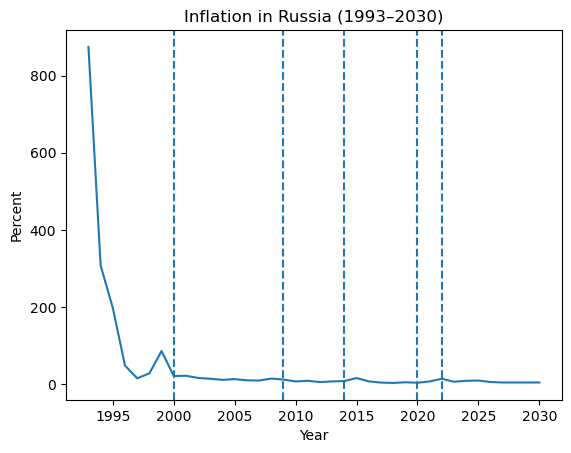

In [92]:
plt.figure()
plt.plot(df_final.index, df_final["Inflation (CPI, %)"])
for y in event_years:
    plt.axvline(y, linestyle="--")
plt.title("Inflation in Russia (1993–2030)")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.show()

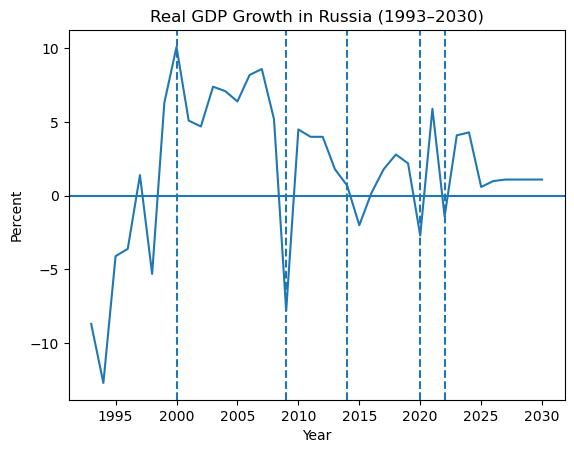

In [93]:
plt.figure()
plt.plot(df_final.index, df_final["Real GDP Growth (%)"])
plt.axhline(0)
for y in event_years:
    plt.axvline(y, linestyle="--")
plt.title("Real GDP Growth in Russia (1993–2030)")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.show()

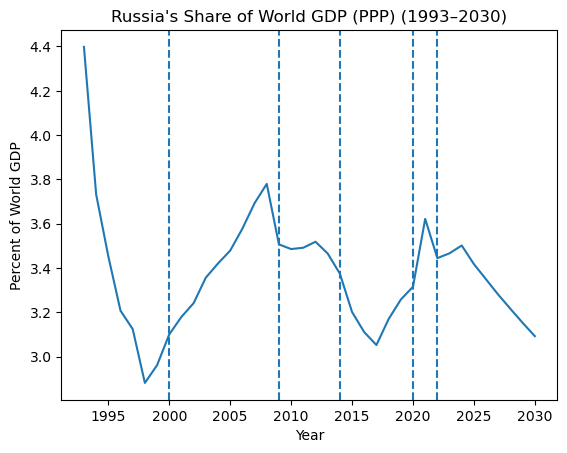

In [94]:
plt.figure()
plt.plot(df_final.index, df_final["Share of World GDP (PPP, %)"])
for y in event_years:
    plt.axvline(y, linestyle="--")
plt.title("Russia's Share of World GDP (PPP) (1993–2030)")
plt.xlabel("Year")
plt.ylabel("Percent of World GDP")
plt.show()

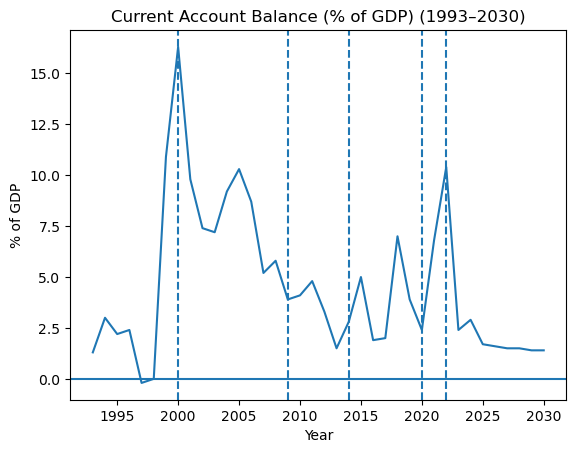

In [95]:
plt.figure()
plt.plot(df_final.index, df_final["Current Account (% of GDP)"])
plt.axhline(0)
for y in event_years:
    plt.axvline(y, linestyle="--")
plt.title("Current Account Balance (% of GDP) (1993–2030)")
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.show()

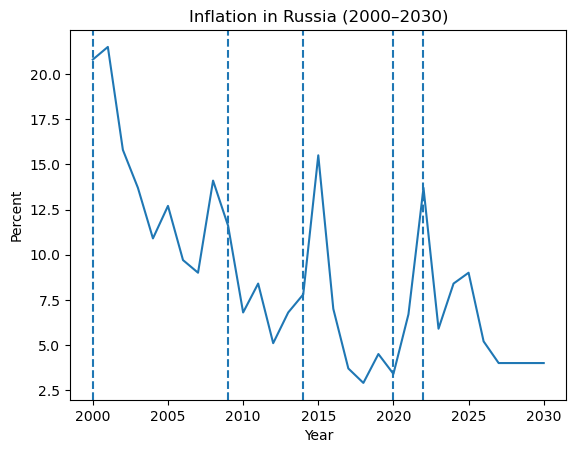

In [96]:
plt.figure()
df_post = df_final[df_final.index >= 2000]
plt.plot(df_post.index, df_post["Inflation (CPI, %)"])
for y in event_years:
    if y >= 2000:
        plt.axvline(y, linestyle="--")
plt.title("Inflation in Russia (2000–2030)")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.show()